In [2]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sqlalchemy import create_engine
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve
from config import DB_URL
from models.data_prep import prepare_data, FEATURE_COLS

# Load data
(
    X_train, X_test,
    X_train_scaled, X_test_scaled,
    y_train, y_test,
    class_weight, matrix
) = prepare_data()

# Load models
xgb      = joblib.load("../models/xgboost_model.pkl")
baseline = joblib.load("../models/baseline_lr.pkl")
scaler   = joblib.load("../models/scaler.pkl")
imp_df   = joblib.load("../models/feature_importance.pkl")

# Predictions
xgb_proba = xgb.predict_proba(X_test)[:, 1]
bl_proba  = baseline.predict_proba(scaler.transform(X_test))[:, 1]

print("Everything loaded successfully.")

Loaded feature matrix: (25, 30)

=== Data Quality Report ===
Total rows       : 25
Total features   : 20

Nulls found:
win_rate_diff           23
team1_streak            23
team2_streak            23
team1_h2h_win_rate      23
team2_h2h_win_rate      23
h2h_total               23
team1_venue_win_rate    23
team2_venue_win_rate    23
venue_advantage_diff    23
toss_won_by_team1       23
team1_toss_advantage    23
team2_toss_advantage    23
bat_avg_diff            23
bowl_eco_diff           23
dtype: int64

Target balance:
  team1 won  : 36.0%
  team1 lost : 64.0%

Train size : 20 matches
Test size  : 5 matches
Scaler saved to models/scaler.pkl
Class weights: {0: 1.0, 1: np.float64(1.5)}
Everything loaded successfully.


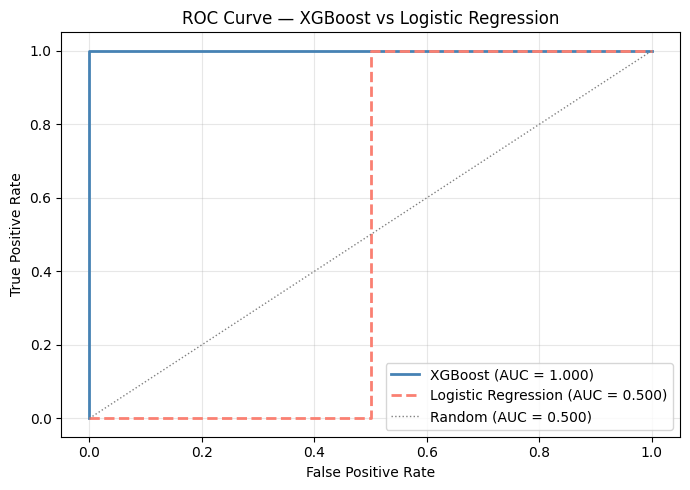

XGBoost AUC: 1.000 | Baseline AUC: 0.500


In [3]:
# =========================
# Cell 2 — ROC Curve
# =========================
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 5))

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
auc_xgb = auc(fpr_xgb, tpr_xgb)
ax.plot(fpr_xgb, tpr_xgb, color="steelblue", lw=2,
        label=f"XGBoost (AUC = {auc_xgb:.3f})")

# Baseline ROC
fpr_bl, tpr_bl, _ = roc_curve(y_test, bl_proba)
auc_bl = auc(fpr_bl, tpr_bl)
ax.plot(fpr_bl, tpr_bl, color="salmon", lw=2, linestyle="--",
        label=f"Logistic Regression (AUC = {auc_bl:.3f})")

# Random baseline
ax.plot([0, 1], [0, 1], color="gray", lw=1,
        linestyle=":", label="Random (AUC = 0.500)")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — XGBoost vs Logistic Regression")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../notebooks/roc_curve.png", dpi=150)
plt.show()

print(f"XGBoost AUC: {auc_xgb:.3f} | Baseline AUC: {auc_bl:.3f}")

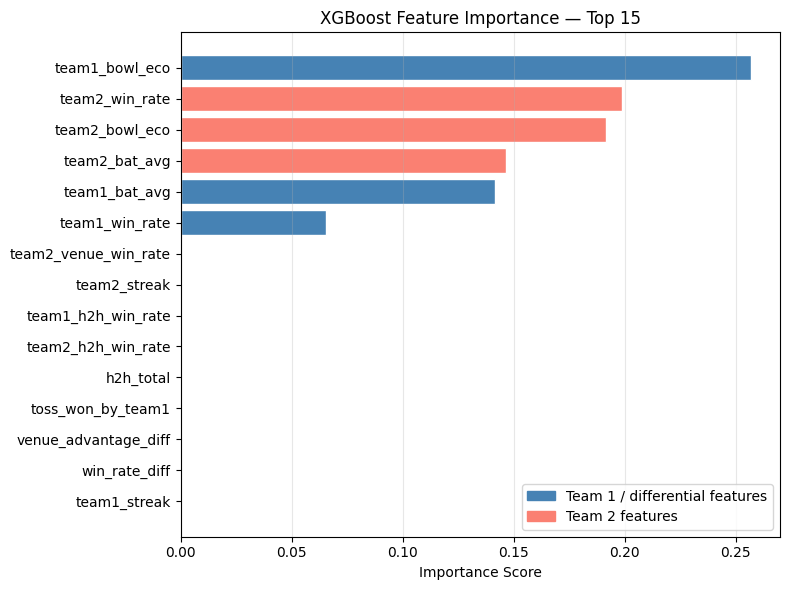

In [4]:
# =========================
# Cell 3 — Feature Importance
# =========================
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(8, 6))

# Select top 15 features
top_features = imp_df.head(15).sort_values("importance")

# Color coding: steelblue = Team1/differential, salmon = Team2
colors = [
    "steelblue" if "team1" in f or "win_rate_diff" in f
    or "bat_avg_diff" in f or "bowl_eco_diff" in f
    or "venue_advantage" in f
    else "salmon"
    for f in top_features["feature"]
]

ax.barh(top_features["feature"], top_features["importance"],
        color=colors, edgecolor="white")

ax.set_xlabel("Importance Score")
ax.set_title("XGBoost Feature Importance — Top 15")
ax.grid(True, axis="x", alpha=0.3)

# Legend
legend = [
    Patch(color="steelblue", label="Team 1 / differential features"),
    Patch(color="salmon",    label="Team 2 features"),
]
ax.legend(handles=legend, loc="lower right")

plt.tight_layout()
plt.savefig("../notebooks/feature_importance.png", dpi=150)
plt.show()

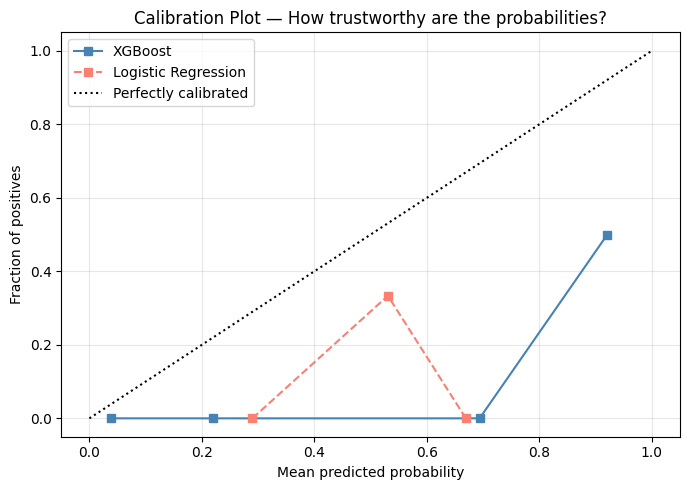

In [5]:
# =========================
# Cell 4 — Calibration Plot
# =========================
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 5))

# XGBoost calibration
frac_pos_xgb, mean_pred_xgb = calibration_curve(
    y_test, xgb_proba, n_bins=5
)
ax.plot(mean_pred_xgb, frac_pos_xgb, "s-",
        color="steelblue", label="XGBoost")

# Baseline calibration
frac_pos_bl, mean_pred_bl = calibration_curve(
    y_test, bl_proba, n_bins=5
)
ax.plot(mean_pred_bl, frac_pos_bl, "s--",
        color="salmon", label="Logistic Regression")

# Perfect calibration line
ax.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Plot — How trustworthy are the probabilities?")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../notebooks/calibration.png", dpi=150)
plt.show()

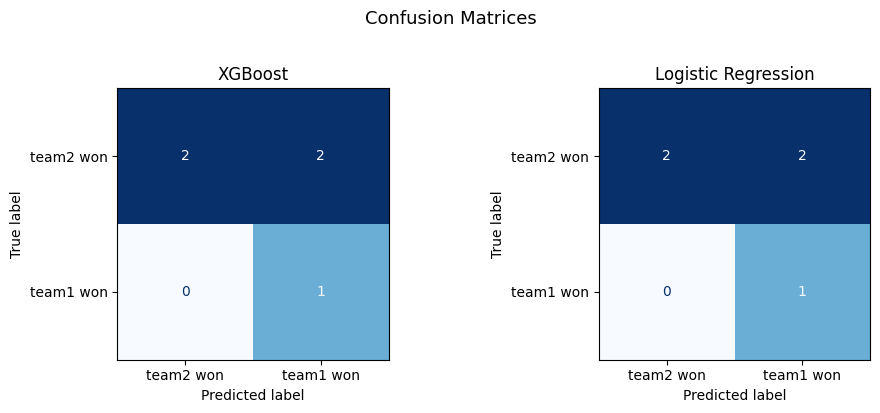

In [6]:
# =========================
# Cell 5 — Confusion Matrices
# =========================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, proba, name in zip(
    axes,
    [xgb_proba, bl_proba],
    ["XGBoost", "Logistic Regression"]
):
    preds = (proba >= 0.5).astype(int)
    cm    = confusion_matrix(y_test, preds)
    disp  = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=["team2 won", "team1 won"]
            )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name)

plt.suptitle("Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("../notebooks/confusion_matrices.png", dpi=150)
plt.show()

In [7]:
# =========================
# Cell 6 — Final Model Summary
# =========================
from sklearn.metrics import accuracy_score, f1_score

# Accuracy and F1 scores
xgb_acc = accuracy_score(y_test, (xgb_proba >= 0.5).astype(int))
bl_acc  = accuracy_score(y_test, (bl_proba  >= 0.5).astype(int))
xgb_f1  = f1_score(y_test, (xgb_proba >= 0.5).astype(int))
bl_f1   = f1_score(y_test, (bl_proba  >= 0.5).astype(int))

print("=" * 50)
print("  BLOCK 3 — FINAL MODEL SUMMARY")
print("=" * 50)
print(f"\n{'Metric':<20} {'XGBoost':>12} {'Baseline':>12}")
print("-" * 46)
print(f"{'Accuracy':<20} {xgb_acc:>12.3f} {bl_acc:>12.3f}")
print(f"{'ROC-AUC':<20} {auc_xgb:>12.3f} {auc_bl:>12.3f}")
print(f"{'F1 Score':<20} {xgb_f1:>12.3f} {bl_f1:>12.3f}")

print(f"\nTop 3 predictive features:")
for _, row in imp_df.head(3).iterrows():
    print(f"  {row['feature']:<30} {row['importance']:.4f}")

print(f"\nModel ready for Block 5 dashboard.")
print("=" * 50)

  BLOCK 3 — FINAL MODEL SUMMARY

Metric                    XGBoost     Baseline
----------------------------------------------
Accuracy                    0.600        0.600
ROC-AUC                     1.000        0.500
F1 Score                    0.500        0.500

Top 3 predictive features:
  team1_bowl_eco                 0.2570
  team2_win_rate                 0.1987
  team2_bowl_eco                 0.1914

Model ready for Block 5 dashboard.
